**Task 7:  Sales Forecasting Description**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("WSF dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')
df.head()

Saving WSF dataset.csv to WSF dataset.csv


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
277665,29,5,2010-02-05,15552.08,False
277808,29,6,2010-02-05,3200.22,False
277951,29,7,2010-02-05,10820.05,False
278094,29,8,2010-02-05,20055.64,False


train/ test split

In [3]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df['quarter'] = df['Date'].dt.quarter

CNN model

In [4]:
df['lag_1'] = df['Weekly_Sales'].shift(1)
df['lag_4'] = df['Weekly_Sales'].shift(4)
df['lag_12'] = df['Weekly_Sales'].shift(12)

df['rolling_mean_4'] = df['Weekly_Sales'].rolling(window=4).mean()
df['rolling_std_4'] = df['Weekly_Sales'].rolling(window=4).std()

df = df.dropna()

In [5]:
features = [
    'year','month','week','day','dayofweek','quarter',
    'lag_1','lag_4','lag_12',
    'rolling_mean_4','rolling_std_4'
]

X = df[features]
y = df['Weekly_Sales']

time aware test split

In [6]:
split_date = df['Date'].max() - pd.Timedelta(weeks=12)

X_train = X[df['Date'] <= split_date]
X_test = X[df['Date'] > split_date]

y_train = y[df['Date'] <= split_date]
y_test = y[df['Date'] > split_date]

Regressin Model

In [16]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [17]:
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

MAE: 11871.755413542163
RMSE: 18108.573044616147


*Bonus--SBG boost*

In [18]:
xgb = XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGB MAE:", mean_absolute_error(y_test, pred_xgb))

XGB MAE: 11780.47231475325


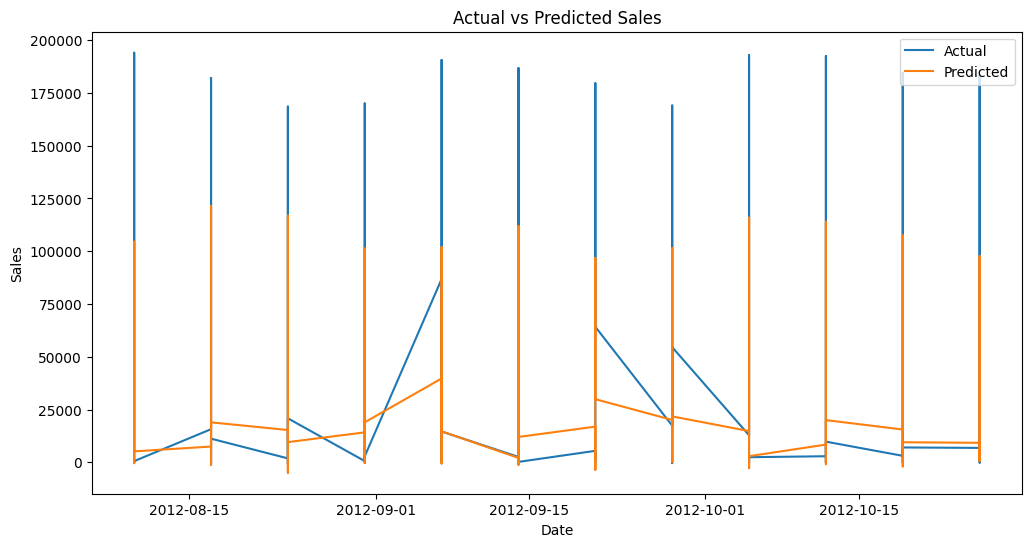

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'][df['Date'] > split_date], y_test, label='Actual')
plt.plot(df['Date'][df['Date'] > split_date], pred_xgb, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

Bonus-1

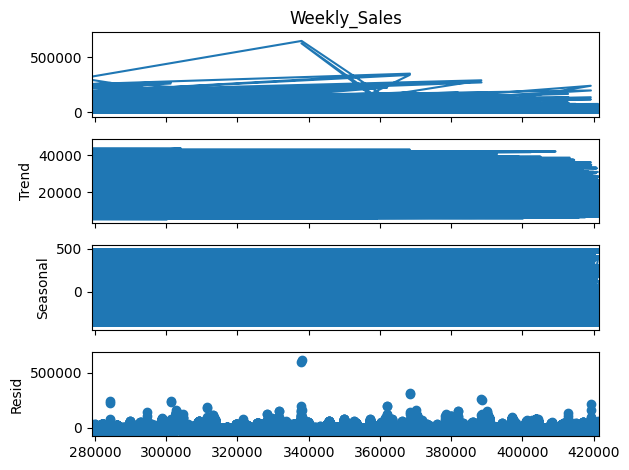

In [20]:
decomposition = seasonal_decompose(
    df['Weekly_Sales'],
    model='additive',
    period=52  # weekly seasonality
)

decomposition.plot()
plt.show()

Bonus-2

In [21]:
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
    y_tr, y_te = y.iloc[train_index], y.iloc[test_index]

    model = XGBRegressor()
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)
    print("Fold MAE:", mean_absolute_error(y_te, preds))

Fold MAE: 12714.120891664192
Fold MAE: 11760.920533306551
Fold MAE: 12224.442934943063
Fold MAE: 12561.221760458486
Fold MAE: 11975.981989945321
